In [52]:
import os
import librosa
import numpy as np
import pandas as pd

folder_path = r"C:\Users\amiru\OneDrive\Desktop\Sound recordings_AUG"  # Audio folder path

mfcc_data = []
labels = []

# Define fixed parameters
n_mfcc = 13
max_len = 120  # number of time steps

# Loop over files
for filename in os.listdir(folder_path):
    if filename.endswith(".wav"):
        path = os.path.join(folder_path, filename)
        label = filename.split("V")[1][0]  # Extract '1', '2', '3', '4'

        try:
            y, sr = librosa.load(path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc).T  # shape: (time, features)

            # Pad or truncate to fixed length
            if mfcc.shape[0] < max_len:
                pad_width = max_len - mfcc.shape[0]
                mfcc = np.pad(mfcc, ((0, pad_width), (0, 0)), mode='constant')
            else:
                mfcc = mfcc[:max_len, :]

            mfcc_data.append(mfcc)
            labels.append(int(label))
        except Exception as e:
            print(f"Error with {filename}: {e}")

# Convert to numpy arrays
X = np.array(mfcc_data)  # Shape: (samples, time_steps, features)
y = np.array(labels)     # Shape: (samples,)

# Save for reuse
np.save("X_mfcc.npy", X)
np.save("y_labels.npy", y)

print(f"Saved {X.shape[0]} samples, each with shape {X.shape[1:]} (time steps x features)")


Saved 6088 samples, each with shape (120, 13) (time steps x features)


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping

# Load preprocessed data
X = np.load("X_mfcc.npy")
y = np.load("y_labels.npy")

# Normalize if needed
X = (X - np.mean(X)) / np.std(X)

# Convert labels to one-hot
y_categorical = to_categorical(y - 1)  # 1-indexed → 0-indexed

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')  # 4 classes
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()


C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 120, 64)        │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,572 (131.14 KB)

 Trainable params: 33,572 (131.14 KB)

 Non-trainable params: 0 (0.00 B)

In [54]:
# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
history = model.fit(X_train, y_train, epochs=40, batch_size=8, validation_split=0.2)

# Save the model
model.save("lstm_verse_classifier.keras")


Epoch 1/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 26s 43ms/step - accuracy: 0.3435 - loss: 1.2952 - val_accuracy: 0.4538 - val_loss: 1.2116
Epoch 2/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.4183 - loss: 1.2200 - val_accuracy: 0.3768 - val_loss: 1.2399
Epoch 3/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.3885 - loss: 1.2594 - val_accuracy: 0.4456 - val_loss: 1.1772
Epoch 4/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 19s 39ms/step - accuracy: 0.4639 - loss: 1.1673 - val_accuracy: 0.5113 - val_loss: 1.0702
Epoch 5/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.5151 - loss: 1.0364 - val_accuracy: 0.5626 - val_loss: 0.9508
Epoch 6/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step - accuracy: 0.6185 - loss: 0.9165 - val_accuracy: 0.7115 - val_loss: 0.7743
Epoch 7/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - accuracy: 0.6695 - loss: 0.8116 - val_accuracy: 0.7310 - val_loss: 0.7133
Epoch 8/40
487/487 ━━━━━━━━━━━━━━━━━━━━ 19s 40ms/step - accuracy: 0.6879 - loss: 0.7628 - 

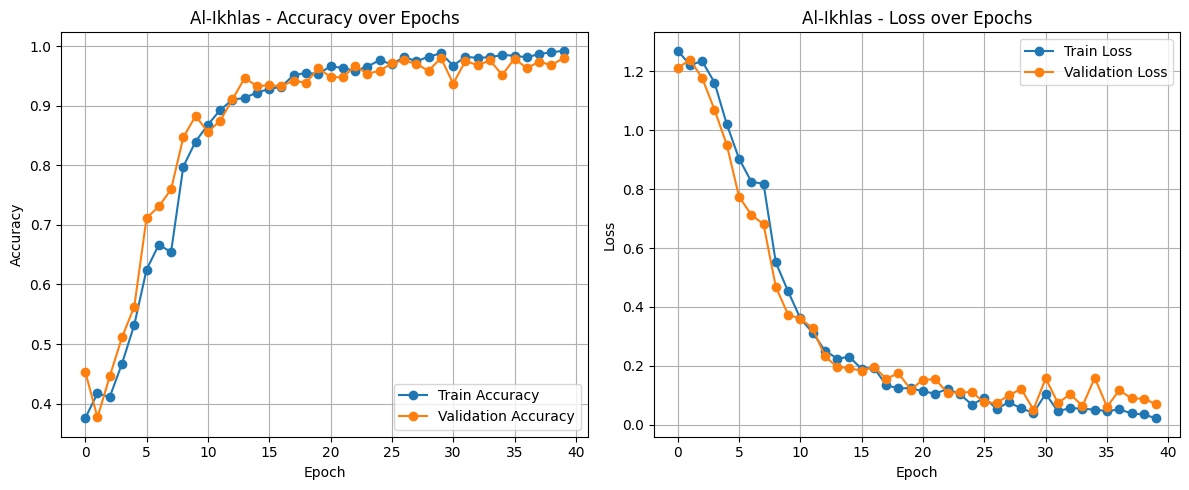

In [55]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Al-Ikhlas - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Al-Ikhlas - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [105]:
import pyaudio
import numpy as np
import librosa
import threading
from tensorflow.keras.models import load_model
import os
import noisereduce as nr
from scipy.signal import butter, lfilter

# Load LSTM model
model = load_model("lstm_verse_classifier.keras")

# Verse mapping
verse_texts = {
    1: "قُلْ هُوَ اللَّهُ أَحَدٌ",
    2: "اللَّهُ الصَّمَدُ",
    3: "لَمْ يَلِدْ وَلَمْ يُولَدْ",
    4: "وَلَمْ يَكُن لَهُۥۤ۟ كُفُوًا أَحَدٌ"
}

# 🎛️ Audio settings
RATE = 16000
CHUNK_DURATION = 6 # seconds
CHUNK_SIZE = RATE * CHUNK_DURATION
N_MFCC = 13
MAX_LEN = 120

stop_flag = False
highlighted_verses = set()
best_prediction = None
best_confidence = 0.0

# ───────────────────────────────────────────────
# 🔊 High-pass filter to remove low-frequency hum
def highpass_filter(audio, sr, cutoff=100, order=5):
    nyquist = 0.5 * sr
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return lfilter(b, a, audio)

# 🧠 Predict verse from audio
def predict_chunk(audio_data):
    # Trim silence
    y_trimmed, _ = librosa.effects.trim(audio_data, top_db=45)
    if len(y_trimmed) == 0:
        return None, 0.0

    # High-pass filter (remove <100 Hz hum)
    y_filtered = highpass_filter(y_trimmed, sr=RATE)

    # Spectral gating / noise reduction
    reduced_audio = nr.reduce_noise(y=y_filtered, sr=RATE, prop_decrease=0.8)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=reduced_audio, sr=RATE, n_mfcc=N_MFCC).T
    if mfcc.shape[0] < MAX_LEN:
        mfcc = np.pad(mfcc, ((0, MAX_LEN - mfcc.shape[0]), (0, 0)), mode='constant')
    else:
        mfcc = mfcc[:MAX_LEN, :]

    # Normalize and predict
    mfcc = (mfcc - np.mean(mfcc)) / np.std(mfcc)
    mfcc = np.expand_dims(mfcc, axis=0)

    prediction = model.predict(mfcc, verbose=0)
    predicted_class = np.argmax(prediction) + 1
    confidence = np.max(prediction)

    return predicted_class, confidence

# 🖥️ Display verses with highlighting
def display_verses(highlight_id=None):
    os.system('cls' if os.name == 'nt' else 'clear')
    print("\n📖 Surah Al-Ikhlas\n")
    for i in range(1, 5):
        verse = verse_texts[i]
        if i == highlight_id:
            print(f">>> 🟢 {verse} <<<")
        elif i in highlighted_verses:
            print(f"✅ {verse}")
        else:
            print(f"⬜ {verse}")
    print("\n🎧 Listening...")

# 🛑 Wait for user input to stop
def wait_for_stop():
    global stop_flag
    input("🔘 Press Enter to stop recitation...\n")
    stop_flag = True

# ───────────────────────────────────────────────
# 🎙️ Start real-time audio stream
p = pyaudio.PyAudio()
stream = p.open(format=pyaudio.paInt16,
                channels=1,
                rate=RATE,
                input=True,
                frames_per_buffer=CHUNK_SIZE)

listener_thread = threading.Thread(target=wait_for_stop)
listener_thread.start()

print("🎙️ Real-Time Surah Al-Ikhlas Recitation Detection Started...\n")
display_verses()

try:
    while not stop_flag:
        audio_data = stream.read(CHUNK_SIZE, exception_on_overflow=False)
        audio_np = np.frombuffer(audio_data, dtype=np.int16).astype(np.float32) / 32768.0

        predicted_class, confidence = predict_chunk(audio_np)

        if predicted_class and confidence > 0.4:
            if confidence > best_confidence:
                best_prediction = predicted_class
                best_confidence = confidence

            highlighted_verses.add(predicted_class)
            display_verses(highlight_id=predicted_class)

except Exception as e:
    print(f"\n❌ Error: {e}")

finally:
    stream.stop_stream()
    stream.close()
    p.terminate()

    print("\n🛑 Recitation ended by user.")
    if best_prediction:
        print("\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print(f"✅ Most Confident Verse: V{best_prediction} | Confidence: {best_confidence:.2f}")
        print(f"🕋 {verse_texts[best_prediction]}")
    else:
        print("⚠️ No confident verse detected.")


🎙️ Real-Time Surah Al-Ikhlas Recitation Detection Started...


📖 Surah Al-Ikhlas

⬜ قُلْ هُوَ اللَّهُ أَحَدٌ
⬜ اللَّهُ الصَّمَدُ
⬜ لَمْ يَلِدْ وَلَمْ يُولَدْ
⬜ وَلَمْ يَكُن لَهُۥۤ۟ كُفُوًا أَحَدٌ

🎧 Listening...

📖 Surah Al-Ikhlas

>>> 🟢 قُلْ هُوَ اللَّهُ أَحَدٌ <<<
⬜ اللَّهُ الصَّمَدُ
⬜ لَمْ يَلِدْ وَلَمْ يُولَدْ
⬜ وَلَمْ يَكُن لَهُۥۤ۟ كُفُوًا أَحَدٌ

🎧 Listening...

🛑 Recitation ended by user.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Most Confident Verse: V1 | Confidence: 1.00
🕋 قُلْ هُوَ اللَّهُ أَحَدٌ
